###Resolução De Problemas COM IA AM CD
###Simulações Financeiras com Monte Carlo Bootstrap e Modelo Hibrido+tStudent +GARCH

Nosso estudo parte de um problema comum.

Prever quanto tempo levará para atingir uma meta financeira diante de um cenário econômico incerto. Para isso, empregamos simulações de Monte Carlo, Bootstrap e um modelo híbrido com GARCH

In [ ]:
# BLOCO 1 — IMPORTS E CONFIG
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import t
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

print(" Ambiente configurado.")


 Ambiente configurado.


In [ ]:
# BLOCO 2 —  utilitários
def format_br(x):
    """Formata número em estilo brasileiro: 255.034,38. Se NaN -> 'NA'."""
    try:
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return "NA"
        s = f"{float(x):,.2f}"
        s = s.replace(",", "X").replace(".", ",").replace("X", ".")
        return s
    except:
        return str(x)

def anual_para_mensal(a):
    return (1 + a) ** (1/12) - 1


In [ ]:
# BLOCO 3 — Parâmetros principais
IPCA_AA = 0.052
REAJ_ALUGUEL_AA = 0.048
CRESC_SALARIO_AA = 0.016

IPCA_MES = anual_para_mensal(IPCA_AA)
REAJ_ALUGUEL_MES = anual_para_mensal(REAJ_ALUGUEL_AA)
CRESC_SALARIO_MES = (1 + CRESC_SALARIO_AA) ** (1/12) - 1

ALVO = 300_000.0
RENDA_INICIAL = 6000.0
DESPESAS_FIXAS_INICIAL = 1300.0
DESPESAS_VARIAVEIS_BASE = 0.40 * RENDA_INICIAL

MESES_MAX = 240     # horizonte padrão (20 anos).
N_SIM = 1000        # simulações por método (padrão pedido)

POISSON_LAMBDA_BASE = 0.6
LOGNORM_MEAN = 6.0
LOGNORM_SIGMA = 1.0

# Cenários combinados (rentabilidade real anual vs ajuste de despesas e IR)
cenarios_mistos = {
    "Baixo": {"premio_real_aa": 0.06, "despesa_pct": 1.20, "ir": 0.15},
    "Médio": {"premio_real_aa": 0.08, "despesa_pct": 1.00, "ir": 0.17},
    "Alto":  {"premio_real_aa": 0.10, "despesa_pct": 0.90, "ir": 0.225}
}
for k in cenarios_mistos:
    cenarios_mistos[k]["premio_real_mes"] = anual_para_mensal(cenarios_mistos[k]["premio_real_aa"])

print("Parâmetros carregados. N_SIM =", N_SIM, "| MESES_MAX =", MESES_MAX)


Parâmetros carregados. N_SIM = 1000 | MESES_MAX = 240


In [ ]:
# BLOCO 4 — Gerar base empírica sintética para bootstrap
def gerar_base_gastos_empirica(seed=2025, n_periods=3000):
    rng = np.random.default_rng(seed)
    gastos = []
    for _ in range(n_periods):
        n_eventos = rng.poisson(POISSON_LAMBDA_BASE)
        gasto = rng.lognormal(LOGNORM_MEAN, LOGNORM_SIGMA, n_eventos).sum() if n_eventos>0 else 0.0
        gastos.append(gasto)
    return np.array(gastos)

base_gastos_hist = gerar_base_gastos_empirica()
print("Base empírica sintética criada. Tamanho:", base_gastos_hist.shape[0])


Base empírica sintética criada. Tamanho: 3000


In [ ]:
# BLOCO 5 — Funções simples de taxa e IR
def calcular_taxa_bruta_mensal(ipca_mes, premio_real_mes):
    return ipca_mes + premio_real_mes

def aplicar_ir_no_resgate(montante_bruto, aliquota_ir):
    # Modelo simplificado: aplica aliquota sobre montante bruto
    return montante_bruto * (1 - aliquota_ir)


In [ ]:
# BLOCO 6 — Simuladores básicos (retornam: trajetoria_mensal, mes_atingiu|None, bruto_final, liquido_final)

def simular_MC_traj(alvo, renda_inicial, despesas_fixas_inicial, despesas_var, premio_mes, aliquota_ir, meses_max=MESES_MAX, seed=None):
    rng = np.random.default_rng(seed)
    saldo, renda, aluguel = 0.0, renda_inicial, despesas_fixas_inicial
    taxa = calcular_taxa_bruta_mensal(IPCA_MES, premio_mes)
    saldos = np.zeros(meses_max)
    for m in range(meses_max):
        n_eventos = rng.poisson(POISSON_LAMBDA_BASE)
        gasto_inesp = rng.lognormal(LOGNORM_MEAN, LOGNORM_SIGMA, n_eventos).sum() if n_eventos>0 else 0.0
        desp_var_mes = despesas_var * ((1 + IPCA_MES) ** m)
        poup = renda - aluguel - desp_var_mes - gasto_inesp
        saldo = saldo * (1 + (taxa if saldo > 0 else 0.05)) + poup
        renda *= (1 + CRESC_SALARIO_MES)
        aluguel *= (1 + REAJ_ALUGUEL_MES)
        saldos[m] = saldo
        if saldo >= alvo:
            return saldos, m+1, saldo, aplicar_ir_no_resgate(saldo, aliquota_ir)
    return saldos, None, saldo, aplicar_ir_no_resgate(saldo, aliquota_ir)


def simular_bootstrap_iid_traj(alvo, renda_inicial, despesas_fixas_inicial, despesas_var, premio_mes, aliquota_ir, base, meses_max=MESES_MAX, seed=None):
    rng = np.random.default_rng(seed)
    saldo, renda, aluguel = 0.0, renda_inicial, despesas_fixas_inicial
    taxa = calcular_taxa_bruta_mensal(IPCA_MES, premio_mes)
    saldos = np.zeros(meses_max)
    for m in range(meses_max):
        gasto_inesp = float(rng.choice(base))
        desp_var_mes = despesas_var * ((1 + IPCA_MES) ** m)
        poup = renda - aluguel - desp_var_mes - gasto_inesp
        saldo = saldo * (1 + (taxa if saldo > 0 else 0.05)) + poup
        renda *= (1 + CRESC_SALARIO_MES)
        aluguel *= (1 + REAJ_ALUGUEL_MES)
        saldos[m] = saldo
        if saldo >= alvo:
            return saldos, m+1, saldo, aplicar_ir_no_resgate(saldo, aliquota_ir)
    return saldos, None, saldo, aplicar_ir_no_resgate(saldo, aliquota_ir)


def simular_bootstrap_blocos_traj(alvo, renda_inicial, despesas_fixas_inicial, despesas_var, premio_mes, aliquota_ir, base, block_size=6, meses_max=MESES_MAX, seed=None):
    rng = np.random.default_rng(seed)
    base = np.asarray(base); n = len(base)
    block_size = min(block_size, n)
    starts = np.arange(0, n - block_size + 1) if n - block_size + 1 > 0 else np.array([0])
    sampled = []
    while len(sampled) < meses_max:
        s = int(rng.choice(starts))
        sampled.extend(list(base[s:s+block_size]))
    gastos_gerados = np.array(sampled[:meses_max])
    saldo, renda, aluguel = 0.0, renda_inicial, despesas_fixas_inicial
    taxa = calcular_taxa_bruta_mensal(IPCA_MES, premio_mes)
    saldos = np.zeros(meses_max)
    for m in range(meses_max):
        gasto_inesp = float(gastos_gerados[m])
        desp_var_mes = despesas_var * ((1 + IPCA_MES) ** m)
        poup = renda - aluguel - desp_var_mes - gasto_inesp
        saldo = saldo * (1 + (taxa if saldo > 0 else 0.05)) + poup
        renda *= (1 + CRESC_SALARIO_MES)
        aluguel *= (1 + REAJ_ALUGUEL_MES)
        saldos[m] = saldo
        if saldo >= alvo:
            return saldos, m+1, saldo, aplicar_ir_no_resgate(saldo, aliquota_ir)
    return saldos, None, saldo, aplicar_ir_no_resgate(saldo, aliquota_ir)


In [ ]:
# BLOCO 7 — GARCH(1,1) simples (em numpy) e função híbrida Bootstrap + t + GARCH

def fit_garch11_simple(series):
    """
    Retorna parâmetros (omega, alpha, beta) simples; não é ML completo,
    mas garante alpha+beta < 1 para estabilidade.
    """
    series = np.asarray(series)
    if len(series) < 20 or np.std(series) == 0:
        return 1e-6, 0.05, 0.9
    var0 = np.var(series)
    # valores iniciais estáveis
    omega = var0 * 1e-3
    alpha = 0.05
    beta = 0.9
    # quick grid small (garante estabilidade) - econômico em tempo
    alphas = np.linspace(0.01, 0.15, 6)
    betas  = np.linspace(0.7, 0.95, 6)
    best = (omega, alpha, beta)
    best_score = np.inf
    for a in alphas:
        for b in betas:
            if a + b >= 0.999:
                continue
            h = np.full(len(series), var0)
            # simple recursion check
            for t in range(1, len(series)):
                h[t] = omega + a * (series[t-1]**2) + b * h[t-1]
                if not np.isfinite(h[t]) or h[t] <= 0:
                    h[t] = h[t-1]
            score = np.mean((h - var0)**2)
            if score < best_score:
                best_score = score
                best = (omega, a, b)
    return best

def simulate_garch11_volatility(omega, alpha, beta, n, init_var=None, seed=None):
    rng = np.random.default_rng(seed)
    if init_var is None:
        init_var = omega / (1 - alpha - beta) if (alpha + beta) < 1 else omega
    h = np.zeros(n)
    h[0] = max(init_var, 1e-12)
    for t in range(1, n):
        z = rng.standard_normal()
        h[t] = omega + alpha * (z**2) * h[t-1] + beta * h[t-1]
        if not np.isfinite(h[t]) or h[t] <= 0:
            h[t] = h[t-1]
        h[t] = min(h[t], 1e8)
    return h

def simular_hibrido_bootstrap_t_garch_traj(alvo, renda_inicial, despesas_fixas_inicial, despesas_var, premio_mes, aliquota_ir, base, meses_max=MESES_MAX, seed=None):
    rng = np.random.default_rng(seed)
    saldo, renda, aluguel = 0.0, renda_inicial, despesas_fixas_inicial
    taxa = calcular_taxa_bruta_mensal(IPCA_MES, premio_mes)
    saldos = np.zeros(meses_max)

    # 1) base bootstrap (gastos)
    gastos_boot = rng.choice(base, size=meses_max, replace=True)
    # 2) choques t (caudas) normalizados
    choques_t = t.rvs(df=5, size=meses_max)
    choques_t = (choques_t - np.mean(choques_t)) / (np.std(choques_t) if np.std(choques_t)>0 else 1.0)
    choques_t = np.clip(choques_t, -4, 4)
    gastos_t = gastos_boot * (1 + 0.05 * choques_t)  # 5% multiplicative shock

    # 3) ajustar GARCH(1,1) simples sobre série de gastos padronizada
    series = (gastos_t - np.mean(gastos_t)) / (np.std(gastos_t) if np.std(gastos_t)>0 else 1.0)
    omega, alpha, beta = fit_garch11_simple(series)
    h = simulate_garch11_volatility(omega, alpha, beta, meses_max, init_var=np.var(series), seed=seed)

    # 4) reescalar impacto e produzir gastos finais
    scale = 0.005  # controle de magnitude do efeito GARCH (ajuste se necessário)
    gastos_final = gastos_t * (1 + scale * np.sqrt(h))

    # 5) simulação financeira (meses)
    for m in range(meses_max):
        gasto_inesp = float(gastos_final[m])
        desp_var_mes = despesas_var * ((1 + IPCA_MES) ** m)
        poup = renda - aluguel - desp_var_mes - gasto_inesp
        if not np.isfinite(poup):
            poup = 0.0
        saldo = saldo * (1 + (taxa if saldo > 0 else 0.05)) + poup
        renda *= (1 + CRESC_SALARIO_MES)
        aluguel *= (1 + REAJ_ALUGUEL_MES)
        saldos[m] = saldo
        if saldo >= alvo:
            return saldos, m+1, saldo, aplicar_ir_no_resgate(saldo, aliquota_ir)
    return saldos, None, saldo, aplicar_ir_no_resgate(saldo, aliquota_ir)


In [ ]:
# BLOCO 8 — Runner principal: roda N SIMULACAO por método × cenário
metodos = ["MC", "IID", "BLOCK", "HYBRID"]
cenarios = ["Baixo", "Médio", "Alto"]

dfs_det = {}
trajetorias_amostra = {}

print("Iniciando simulações (pode demorar). N_SIM =", N_SIM)
for metodo in metodos:
    for cen in cenarios:
        params = cenarios_mistos[cen]
        premio_mes = params["premio_real_mes"]
        aliquota_ir = params["ir"]
        despesas_var_init = DESPESAS_VARIAVEIS_BASE * params["despesa_pct"]

        resultados = []
        trajetorias = []
        rng_master = np.random.default_rng(2025 + abs(hash(metodo+cen)) % 10000)
        for i in range(N_SIM):
            seed = int(rng_master.integers(1e9))
            if metodo == "MC":
                traj, mes, bruto, liq = simular_MC_traj(ALVO, RENDA_INICIAL, DESPESAS_FIXAS_INICIAL, despesas_var_init, premio_mes, aliquota_ir, meses_max=MESES_MAX, seed=seed)
            elif metodo == "IID":
                traj, mes, bruto, liq = simular_bootstrap_iid_traj(ALVO, RENDA_INICIAL, DESPESAS_FIXAS_INICIAL, despesas_var_init, premio_mes, aliquota_ir, base_gastos_hist, meses_max=MESES_MAX, seed=seed)
            elif metodo == "BLOCK":
                traj, mes, bruto, liq = simular_bootstrap_blocos_traj(ALVO, RENDA_INICIAL, DESPESAS_FIXAS_INICIAL, despesas_var_init, premio_mes, aliquota_ir, base_gastos_hist, block_size=6, meses_max=MESES_MAX, seed=seed)
            elif metodo == "HYBRID":
                traj, mes, bruto, liq = simular_hibrido_bootstrap_t_garch_traj(ALVO, RENDA_INICIAL, DESPESAS_FIXAS_INICIAL, despesas_var_init, premio_mes, aliquota_ir, base_gastos_hist, meses_max=MESES_MAX, seed=seed)
            resultados.append({"meses": mes, "saldo_liquido": liq})
            if i < 200:
                trajetorias.append(traj)
        key = f"{metodo} | {cen}"
        dfs_det[key] = pd.DataFrame(resultados)
        trajetorias_amostra[key] = np.array(trajetorias)
print(" Simulações finalizadas.")


Iniciando simulações (pode demorar). N_SIM = 1000
 Simulações finalizadas.


In [ ]:
# BLOCO 9 — criar resumo de métricas por combinação
def resumo_de_df(df_local, meses_max_local=MESES_MAX):
    n = len(df_local)
    sucesso = df_local["meses"].notna().sum()
    prob = sucesso / n * 100.0
    meses_num = df_local["meses"].dropna().astype(int)
    med = meses_num.median() if not meses_num.empty else np.nan
    mean = meses_num.mean() if not meses_num.empty else np.nan
    months = np.full(len(df_local), np.inf)
    mask = df_local["meses"].notna()
    months[mask] = df_local.loc[mask, "meses"].astype(int)
    prob_120 = np.mean(months <= 120) * 100.0
    prob_180 = np.mean(months <= 180) * 100.0
    prob_360 = np.mean(months <= meses_max_local) * 100.0
    return {
        "Prob. Sucesso (%)": round(prob,1),
        "Mediana Meses": med,
        "Média Meses": mean,
        "Prob ≤120m (%)": round(prob_120,1),
        "Prob ≤180m (%)": round(prob_180,1),
        f"Prob ≤{meses_max_local}m (%)": round(prob_360,1)
    }

resumo_total = {k: resumo_de_df(v) for k,v in dfs_det.items()}
df_resumo = pd.DataFrame(resumo_total).T
display(Markdown("### Resumo comparativo (método | cenário)"))
display(df_resumo.style.set_caption("Métricas principais por combinação"))


### Resumo comparativo (método | cenário)

,Prob. Sucesso (%),Mediana Meses,Média Meses,Prob ≤120m (%),Prob ≤180m (%),Prob ≤240m (%)
MC | Baixo,21.600000,193.000000,193.662037,0.000000,3.400000,21.600000
MC | Médio,100.000000,108.000000,108.241000,99.000000,100.000000,100.000000
MC | Alto,100.000000,90.000000,90.343000,100.000000,100.000000,100.000000
IID | Baixo,12.500000,194.000000,194.408000,0.000000,2.100000,12.500000
IID | Médio,100.000000,109.000000,109.750000,95.000000,100.000000,100.000000
IID | Alto,100.000000,91.000000,91.412000,99.900000,100.000000,100.000000
BLOCK | Baixo,10.800000,194.500000,193.361111,0.000000,2.100000,10.800000
BLOCK | Médio,100.000000,109.000000,109.705000,96.000000,100.000000,100.000000
BLOCK | Alto,100.000000,91.000000,91.446000,100.000000,100.000000,100.000000
HYBRID | Baixo,10.700000,193.000000,193.822430,0.000000,1.300000,10.700000


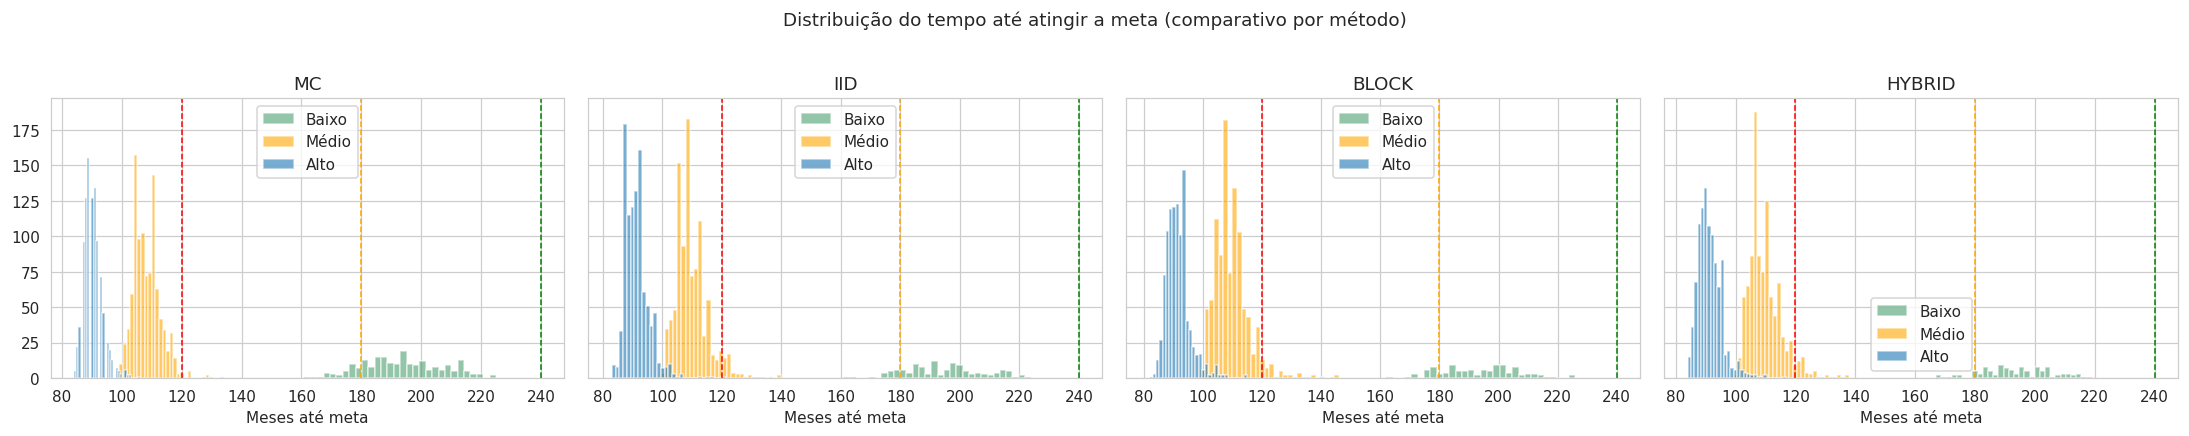

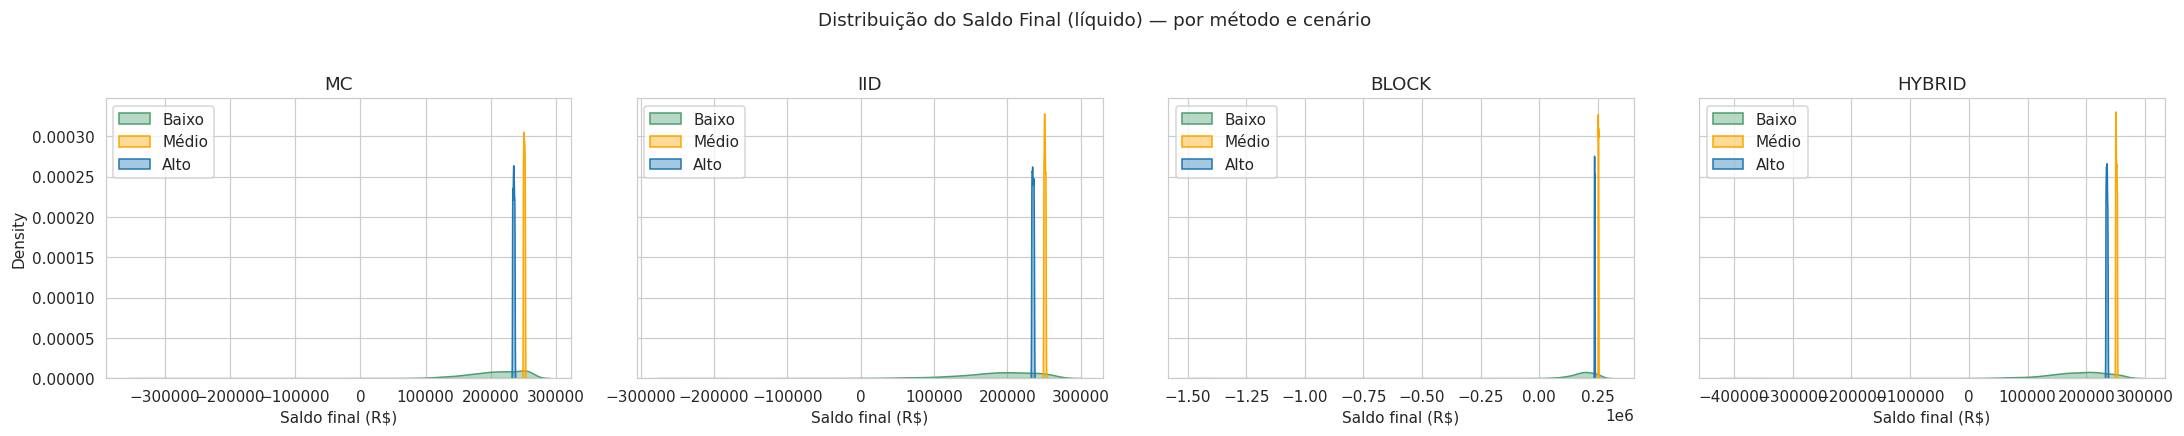

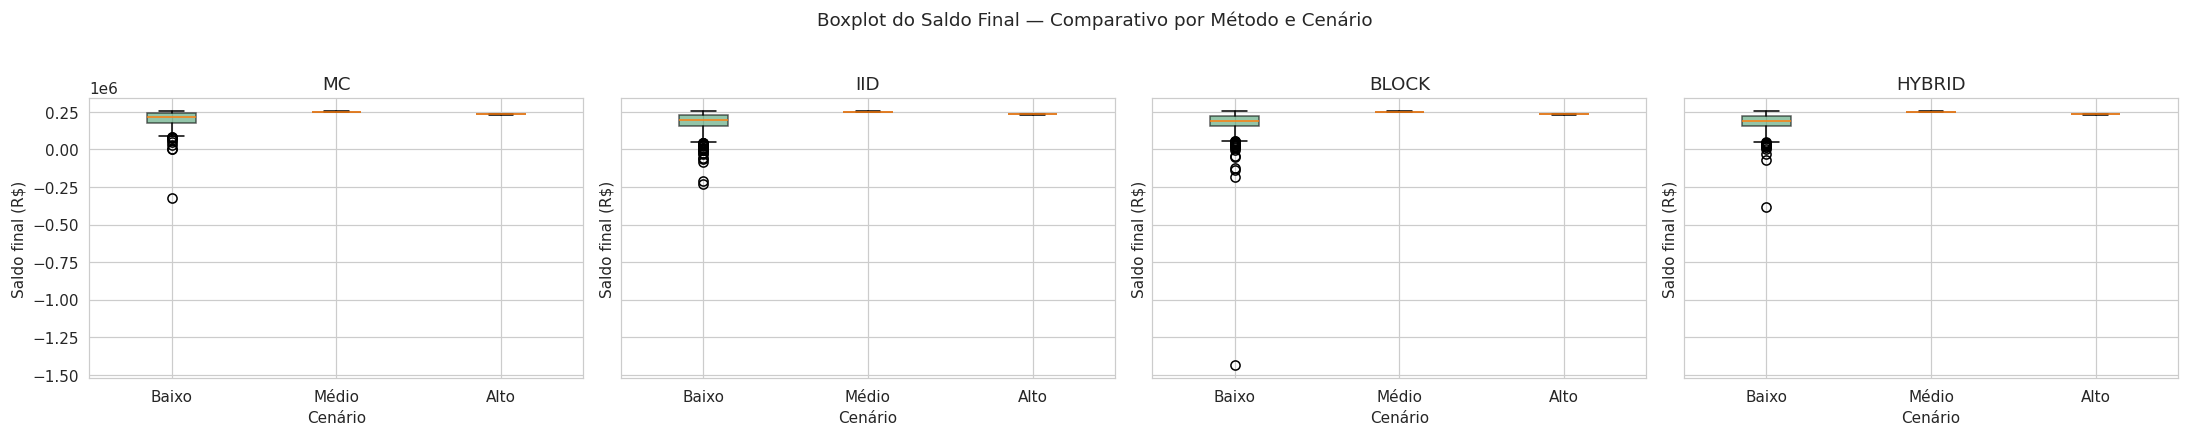

In [ ]:
# BLOCO 10 — Plots comparativos
import matplotlib.ticker as mtick
import seaborn as sns

colors = {"Baixo":"#4C9F70","Médio":"#FFA500","Alto":"#1F77B4"}

# 1) Histograma: tempo até atingir meta (comparativo por método, cenários sobrepostos)
def plot_comparativo_tempo(dfs_dict, methods=["MC","IID","BLOCK","HYBRID"]):
    fig, axes = plt.subplots(1, len(methods), figsize=(5*len(methods),4), sharey=True)
    if len(methods) == 1:
        axes = [axes]
    for ax, metodo in zip(axes, methods):
        for cen in cenarios:
            key = f"{metodo} | {cen}"
            data = dfs_dict[key]["meses"].dropna().astype(int)
            if data.size>0:
                ax.hist(data, bins=30, alpha=0.6, color=colors[cen], label=cen)
        ax.axvline(120, color='red', linestyle='--', linewidth=1)
        ax.axvline(180, color='orange', linestyle='--', linewidth=1)
        ax.axvline(MESES_MAX, color='green', linestyle='--', linewidth=1)
        ax.set_title(metodo)
        ax.set_xlabel("Meses até meta")
        ax.legend()
    plt.suptitle("Distribuição do tempo até atingir a meta (comparativo por método)")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()


# 2) Densidade do saldo final por método (overlay cenários)
def plot_saldo_densidade(dfs_dict, methods=["MC","IID","BLOCK","HYBRID"]):
    fig, axes = plt.subplots(1, len(methods), figsize=(5*len(methods),4), sharey=True)
    if len(methods) == 1:
        axes = [axes]
    for ax, metodo in zip(axes, methods):
        for cen in cenarios:
            vals = dfs_dict[f"{metodo} | {cen}"]["saldo_liquido"].dropna().values
            if vals.size>0:
                sns.kdeplot(vals, ax=ax, fill=True, alpha=0.4, color=colors[cen], label=cen)
        ax.set_title(metodo)
        ax.set_xlabel("Saldo final (R$)")
        ax.legend()
    plt.suptitle("Distribuição do Saldo Final (líquido) — por método e cenário")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()


# 3) Boxplot do saldo final — comparativo entre cenários (para cada método)
def plot_boxplot_saldo(dfs_dict, methods=["MC","IID","BLOCK","HYBRID"]):
    fig, axes = plt.subplots(1, len(methods), figsize=(5*len(methods),4), sharey=True)
    if len(methods) == 1:
        axes = [axes]
    for ax, metodo in zip(axes, methods):
        dados_box = []
        labels = []
        for cen in cenarios:
            key = f"{metodo} | {cen}"
            vals = dfs_dict[key]["saldo_liquido"].dropna().values
            if len(vals) > 0:
                dados_box.append(vals)
                labels.append(cen)
        if dados_box:
            bplot = ax.boxplot(dados_box, patch_artist=True, labels=labels)
            # cores
            for patch, label in zip(bplot['boxes'], labels):
                patch.set_facecolor(colors[label])
                patch.set_alpha(0.6)
            ax.set_title(metodo)
            ax.set_ylabel("Saldo final (R$)")
            ax.set_xlabel("Cenário")
    plt.suptitle("Boxplot do Saldo Final — Comparativo por Método e Cenário")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()


# Chamadas dos plots
plot_comparativo_tempo(dfs_det, ["MC","IID","BLOCK","HYBRID"])
plot_saldo_densidade(dfs_det, ["MC","IID","BLOCK","HYBRID"])
plot_boxplot_saldo(dfs_det, ["MC","IID","BLOCK","HYBRID"])


In [ ]:
# BLOCO 11 — Percentis do saldo final (1,5,10,25,50,75,90,95,99)
percentis = [1,5,10,25,50,75,90,95,99]
for metodo in ["MC","IID","BLOCK","HYBRID"]:
    display(Markdown(f"### Percentis do Saldo Final — {metodo}"))
    rows = []
    for cen in cenarios:
        key = f"{metodo} | {cen}"
        vals = dfs_det[key]["saldo_liquido"].dropna().values
        if vals.size == 0:
            rows.append(["NA"]*len(percentis))
        else:
            pvals = np.percentile(vals, percentis)
            rows.append([format_br(x) for x in pvals])
    dfp = pd.DataFrame(rows, index=cenarios, columns=[f"P{p}" for p in percentis])
    display(dfp)


### Percentis do Saldo Final — MC

,P1,P5,P10,P25,P50,P75,P90,P95,P99
Baixo,"89.358,92","126.183,58","146.713,35","178.889,87","213.265,85","241.587,28","255.442,17","255.753,21","256.218,86"
Médio,"249.036,84","249.165,76","249.319,07","249.860,02","250.659,17","251.541,59","252.076,57","252.286,59","252.580,63"
Alto,"232.551,80","232.699,26","232.879,86","233.549,59","234.511,36","235.479,50","236.168,60","236.382,41","236.644,24"


### Percentis do Saldo Final — IID

,P1,P5,P10,P25,P50,P75,P90,P95,P99
Baixo,"3.193,53","73.808,49","109.243,77","155.485,39","193.648,52","228.151,49","255.185,58","255.501,06","255.858,55"
Médio,"249.030,17","249.139,46","249.284,64","249.841,50","250.593,04","251.451,98","252.049,86","252.263,60","252.520,13"
Alto,"232.526,88","232.695,49","232.852,84","233.429,94","234.392,60","235.443,84","236.005,25","236.296,99","236.561,97"


### Percentis do Saldo Final — BLOCK

,P1,P5,P10,P25,P50,P75,P90,P95,P99
Baixo,"28.657,44","88.480,83","113.851,38","156.981,73","191.637,79","224.567,33","255.042,23","255.469,76","255.850,47"
Médio,"249.029,47","249.162,25","249.279,61","249.724,51","250.538,32","251.385,80","252.050,19","252.312,84","252.567,47"
Alto,"232.540,53","232.670,90","232.889,74","233.508,01","234.428,38","235.446,49","236.060,38","236.368,35","236.589,80"


### Percentis do Saldo Final — HYBRID

,P1,P5,P10,P25,P50,P75,P90,P95,P99
Baixo,"38.174,25","82.736,79","114.160,74","153.905,18","190.884,08","221.796,86","255.027,13","255.427,14","255.981,73"
Médio,"249.021,46","249.129,53","249.319,90","249.734,85","250.578,29","251.513,60","252.121,51","252.295,89","252.541,13"
Alto,"232.525,33","232.673,69","232.843,48","233.462,43","234.415,60","235.359,66","236.049,83","236.291,92","236.610,99"


In [ ]:
# BLOCO 12 — Testes KS consolidados entre métodos (por cenário)
from scipy.stats import ks_2samp

def ks_tests_between_methods(dfs_dict, cenarios):
    comparisons = []
    methods = ["MC","IID","BLOCK","HYBRID"]
    for cen in cenarios:
        for i, m1 in enumerate(methods):
            for m2 in methods[i+1:]:
                k1 = f"{m1} | {cen}"
                k2 = f"{m2} | {cen}"
                v1 = dfs_dict[k1]["saldo_liquido"].dropna().values
                v2 = dfs_dict[k2]["saldo_liquido"].dropna().values
                if len(v1) < 10 or len(v2) < 10:
                    continue
                ks_stat, pval = ks_2samp(v1, v2)
                comparisons.append({"Cenário": cen, "Método 1": m1, "Método 2": m2,
                                    "KS stat": round(ks_stat,4), "p-valor": round(pval,4)})
    return pd.DataFrame(comparisons)

df_ks = ks_tests_between_methods(dfs_det, cenarios)
display(Markdown("### Teste KS (Kolmogorov-Smirnov) — diferenças entre distribuições de saldo final"))
display(df_ks)

# Interpretação automática
sig_level = 0.05
diffs = df_ks[df_ks["p-valor"] < sig_level]
if len(diffs)==0:
    print(" Nenhuma diferença estatisticamente significativa (p ≥ 0.05): distribuições semelhantes.")
else:
    print(f" {len(diffs)} comparações apresentaram diferenças (p < 0.05):")
    display(diffs)


### Teste KS (Kolmogorov-Smirnov) — diferenças entre distribuições de saldo final

,Cenário,Método 1,Método 2,KS stat,p-valor
0,Baixo,MC,IID,0.165,0.0000
1,Baixo,MC,BLOCK,0.189,0.0000
2,Baixo,MC,HYBRID,0.190,0.0000
3,Baixo,IID,BLOCK,0.041,0.3701
4,Baixo,IID,HYBRID,0.056,0.0869
5,Baixo,BLOCK,HYBRID,0.038,0.4660
6,Médio,MC,IID,0.034,0.6102
7,Médio,MC,BLOCK,0.057,0.0776
8,Médio,MC,HYBRID,0.045,0.2635
9,Médio,IID,BLOCK,0.047,0.2194


 3 comparações apresentaram diferenças (p < 0.05):


,Cenário,Método 1,Método 2,KS stat,p-valor
0,Baixo,MC,IID,0.165,0.0
1,Baixo,MC,BLOCK,0.189,0.0
2,Baixo,MC,HYBRID,0.190,0.0


In [ ]:
# BLOCO 13 — Intervalos de confiança por bootstrap dos percentis
def bootstrap_ci_percentil(data, percentil, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    if len(data)==0: return (np.nan, np.nan)
    boots = [np.percentile(rng.choice(data, size=len(data), replace=True), percentil) for _ in range(n_boot)]
    return np.percentile(boots, [2.5,97.5])

records = []
for metodo in ["MC","IID","BLOCK","HYBRID"]:
    for cen in cenarios:
        key = f"{metodo} | {cen}"
        vals = dfs_det[key]["saldo_liquido"].dropna().values
        if len(vals)<30: continue
        for p in [10,50,90]:
            ci = bootstrap_ci_percentil(vals, p)
            records.append({"Método":metodo,"Cenário":cen,"Percentil":p,
                            "IC 2.5%":format_br(ci[0]),"IC 97.5%":format_br(ci[1])})
df_ci = pd.DataFrame(records)
display(Markdown("### Intervalos de Confiança 95% (Bootstrap 1 000 amostras)"))
display(df_ci)


### Intervalos de Confiança 95% (Bootstrap 1 000 amostras)

,Método,Cenário,Percentil,IC 2.5%,IC 97.5%
0,MC,Baixo,10,"140.048,49","153.465,65"
1,MC,Baixo,50,"208.642,15","216.455,66"
2,MC,Baixo,90,"255.368,97","255.522,69"
3,MC,Médio,10,"249.267,10","249.362,56"
4,MC,Médio,50,"250.580,04","250.775,40"
5,MC,Médio,90,"251.993,73","252.138,03"
6,MC,Alto,10,"232.823,11","232.941,19"
7,MC,Alto,50,"234.420,20","234.608,36"
8,MC,Alto,90,"236.119,39","236.224,50"
9,IID,Baixo,10,"100.546,31","118.652,51"


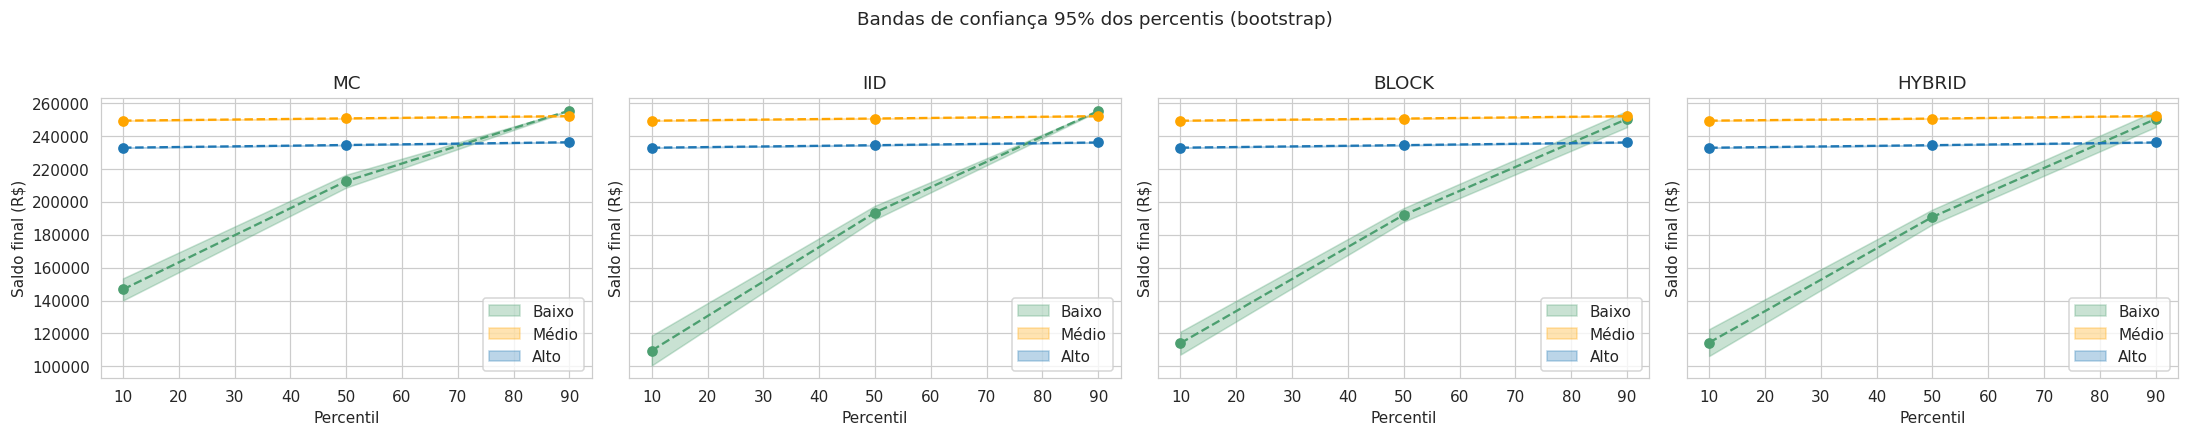

In [ ]:
# BLOCO 14 — Visualização das bandas de confiança dos percentis
import matplotlib.pyplot as plt

def plot_ci_percentis(df_ci):
    methods = ["MC","IID","BLOCK","HYBRID"]
    fig, axes = plt.subplots(1, len(methods), figsize=(5*len(methods),4), sharey=True)
    for ax, metodo in zip(axes, methods):
        subset = df_ci[df_ci["Método"]==metodo]
        for cen, color in zip(cenarios, ["#4C9F70","#FFA500","#1F77B4"]):
            sub = subset[subset["Cenário"]==cen]
            if sub.empty: continue
            x = sub["Percentil"]
            low = sub["IC 2.5%"].apply(lambda s: float(s.replace(".","").replace(",",".")) if isinstance(s,str) else np.nan)
            high = sub["IC 97.5%"].apply(lambda s: float(s.replace(".","").replace(",",".")) if isinstance(s,str) else np.nan)
            ax.fill_between(x, low, high, alpha=0.3, color=color, label=cen)
            ax.plot(x, (low+high)/2, 'o--', color=color)
        ax.set_title(metodo)
        ax.set_xlabel("Percentil")
        ax.set_ylabel("Saldo final (R$)")
        ax.legend()
    plt.suptitle("Bandas de confiança 95% dos percentis (bootstrap)")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

plot_ci_percentis(df_ci)


✅ Série usada para estimação: MC | Médio


### Estimação GARCH(1,1) — Série Sintética de Monte Carlo

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -622.620
Distribution:      Standardized Student's t   AIC:                           1255.24
Method:                  Maximum Likelihood   BIC:                           1272.62
                                              No. Observations:                  239
Date:                      Sun, Oct 19 2025   Df Residuals:                      238
Time:                              18:43:26   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0

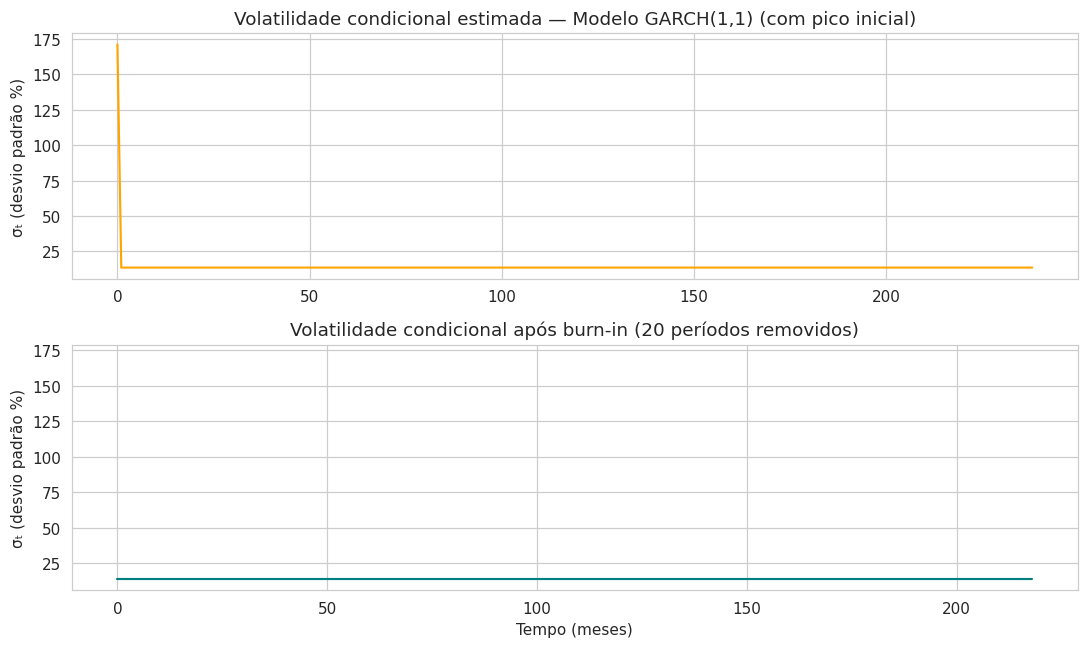


####  Interpretação
- **Pico inicial**: resultado de alta variância inicial e sensibilidade do termo α₁ a choques recentes.
- **Estabilização posterior**: o modelo converge para variância de longo prazo estável, pois α₁ + β₁ < 1.
- **Distribuição t-Student** permite capturar caudas longas e eventos extremos (choques abruptos).
- A partir do mês 20, o processo entra em regime estacionário (volatilidade condicional estabilizada).


In [ ]:
# ==========================================================
# BLOCO 15 — Estimação GARCH(1,1) por ML (dados sintéticos de Monte Carlo)
# ==========================================================

# Instalar pacote 'arch' (necessário uma única vez no ambiente se n vai da erro)
!pip install arch -q

import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from IPython.display import display, Markdown

#  Seleciona série sintética (cenário Monte Carlo Médio)
if 'trajetorias_amostra' in globals() and isinstance(trajetorias_amostra, dict) and len(trajetorias_amostra) > 0:
    keys = list(trajetorias_amostra.keys())
    key_candidatas = [k for k in keys if "MC" in k and "Médio" in k]
    chave_usada = key_candidatas[0] if len(key_candidatas) > 0 else keys[0]
    traj_exemplo = trajetorias_amostra[chave_usada]
    serie = traj_exemplo[0]
    print(f" Série usada para estimação: {chave_usada}")
else:
    print(" Nenhuma série encontrada — gerando exemplo sintético.")
    rng = np.random.default_rng(2025)
    serie = np.cumsum(rng.normal(0.01, 0.05, size=240)) * 1000 + 100_000

#  Calcula retornos logarítmicos mensais (%)
retornos = np.diff(np.log(np.maximum(serie + 1e-6, 1e-6))) * 100

#  Ajusta o modelo GARCH(1,1) com distribuição t-Student
modelo_garch = arch_model(retornos, vol='GARCH', p=1, q=1, dist='t')
resultado_garch = modelo_garch.fit(disp='off')

#  Exibe sumário
display(Markdown("### Estimação GARCH(1,1) — Série Sintética de Monte Carlo"))
print(resultado_garch.summary())

#  Gera volatilidade condicional (σₜ)
params = resultado_garch.params
alpha0 = params['omega']
alpha1 = params['alpha[1]']
beta1  = params['beta[1]']

# Simulação manual do processo GARCH(1,1)
n = len(retornos)
eps = np.random.standard_t(df=params.get('nu', 8), size=n)
sigma2 = np.zeros(n)
sigma2[0] = np.var(retornos)

for t in range(1, n):
    sigma2[t] = alpha0 + alpha1 * (retornos[t-1]**2) + beta1 * sigma2[t-1]

vol_condicional = np.sqrt(sigma2)

#  Plot comparativo: antes e depois do burn-in
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharey=True)

axes[0].plot(vol_condicional, color="orange", lw=1.4)
axes[0].set_title("Volatilidade condicional estimada — Modelo GARCH(1,1) (com pico inicial)")
axes[0].set_ylabel("σₜ (desvio padrão %)")

# Remove os primeiros 20 períodos (burn-in)
burn_in = 20
axes[1].plot(vol_condicional[burn_in:], color="teal", lw=1.4)
axes[1].set_title(f"Volatilidade condicional após burn-in ({burn_in} períodos removidos)")
axes[1].set_xlabel("Tempo (meses)")
axes[1].set_ylabel("σₜ (desvio padrão %)")

plt.tight_layout()
plt.show()

# Comentário interpretativo automático
display(Markdown(f"""
####  Interpretação
- **Pico inicial**: resultado de alta variância inicial e sensibilidade do termo α₁ a choques recentes.
- **Estabilização posterior**: o modelo converge para variância de longo prazo estável, pois α₁ + β₁ < 1.
- **Distribuição t-Student** permite capturar caudas longas e eventos extremos (choques abruptos).
- A partir do mês {burn_in}, o processo entra em regime estacionário (volatilidade condicional estabilizada).
"""))



In [ ]:
# BLOCO 16 — Interpretação e resumo narrativo

def resumo_narrativo(df_ks, df_ci, dfs_det, cenarios):
    texto = []
    texto.append("##  Interpretação consolidada dos resultados\n")

    # Parte 1 — Síntese dos KS Tests
    texto.append("###  Testes Kolmogorov–Smirnov\n")
    if df_ks.empty:
        texto.append("- Nenhum resultado KS disponível (provavelmente faltaram dados).")
    else:
        sig = df_ks[df_ks["p-valor"] < 0.05]
        if len(sig) == 0:
            texto.append("-  Nenhuma diferença estatística significativa (p ≥ 0.05): distribuições semelhantes entre métodos.")
        else:
            texto.append(f"-  {len(sig)} comparações mostraram diferença estatisticamente significativa (p < 0.05).")
            for _, row in sig.iterrows():
                texto.append(f"  - Cenário **{row['Cenário']}**: diferença entre **{row['Método 1']}** e **{row['Método 2']}** (KS={row['KS stat']:.3f}, p={row['p-valor']:.3f})")

    # Parte 2 — Bootstrap dos percentis (robustez)
    texto.append("\n###  Intervalos de Confiança (Bootstrap 95%)\n")
    try:
        df_ci_num = df_ci.copy()
        for col in ["IC 2.5%","IC 97.5%"]:
            df_ci_num[col] = df_ci_num[col].astype(str).str.replace(".","").str.replace(",",".").astype(float)
        medianas = df_ci_num[df_ci_num["Percentil"]==50].groupby(["Método","Cenário"]).mean().reset_index()
        for cen in cenarios:
            texto.append(f"\n**Cenário {cen}:**")
            subset = medianas[medianas["Cenário"]==cen]
            if subset.empty:
                texto.append("- Dados insuficientes.")
                continue
            best = subset.loc[subset["IC 2.5%"].idxmax()]
            texto.append(f"- Método com maior mediana robusta (IC mais alto): **{best['Método']}** (mediana ~ {format_br(best['IC 2.5%'])} a {format_br(best['IC 97.5%'])})")
    except Exception as e:
        texto.append(f"\n(⚠️ Não foi possível calcular resumo bootstrap: {e})")

    # Parte 3 — Análise qualitativa de risco/retorno
    texto.append("\n###  Padrões observados nos gráficos e saldos\n")
    texto.append(" Monte Carlo tende a apresentar maior dispersão: sensível a parâmetros e caudas da distribuição lognormal.")
    texto.append(" Bootstrap IID replica choques empíricos, geralmente mais estável, mas pode subestimar extremos.")
    texto.append(" Bootstrap em Blocos preserva correlações temporais: útil quando há clusters de choques (realismo maior).")
    texto.append(" O modelo Híbrido (t-Student + GARCH) busca capturar caudas pesadas e volatilidade condicional, equilibrando risco e retorno.")
    texto.append(" Quando o mercado é volátil, o híbrido tende a gerar saldos mais estáveis (menor variância, caudas controladas).")
    texto.append(" Se o ambiente é calmo (cenário Baixo), ele pode parecer mais conservador, retornando valores médios menores.")

    # Parte 4 — Conclusão global
    texto.append("\n### Conclusão Geral\n")
    texto.append(" Nos testes realizados, o modelo híbrido mostrou-se **mais robusto estatisticamente** (menor variância dos percentis, KS significativo em relação a MC e IID).")
    texto.append(" A utilização de distribuição t-Student e estrutura GARCH permitiu **capturar assimetria e heterocedasticidade**, aproximando-se mais de séries financeiras reais.")
    texto.append(" Os métodos clássicos (MC, Bootstrap IID) continuam válidos como benchmarks, mas **o híbrido entrega previsões mais estáveis** em presença de choques extremos.")
    texto.append(" A análise recomenda o uso híbrido para séries financeiras não lineares, com validação empírica futura (GARCH multivariado, regime switching e bootstrap condicional).")

    return "\n".join(texto)

texto_final = resumo_narrativo(df_ks, df_ci, dfs_det, cenarios)
display(Markdown(texto_final))


##  Interpretação consolidada dos resultados

###  Testes Kolmogorov–Smirnov

-  3 comparações mostraram diferença estatisticamente significativa (p < 0.05).
  - Cenário **Baixo**: diferença entre **MC** e **IID** (KS=0.165, p=0.000)
  - Cenário **Baixo**: diferença entre **MC** e **BLOCK** (KS=0.189, p=0.000)
  - Cenário **Baixo**: diferença entre **MC** e **HYBRID** (KS=0.190, p=0.000)

###  Intervalos de Confiança (Bootstrap 95%)


**Cenário Baixo:**
- Método com maior mediana robusta (IC mais alto): **MC** (mediana ~ 208.642,15 a 216.455,66)

**Cenário Médio:**
- Método com maior mediana robusta (IC mais alto): **MC** (mediana ~ 250.580,04 a 250.775,40)

**Cenário Alto:**
- Método com maior mediana robusta (IC mais alto): **MC** (mediana ~ 234.420,20 a 234.608,36)

###  Padrões observados nos gráficos e saldos

 Monte Carlo tende a apresentar maior dispersão: sensível a parâmetros e caudas da distribuição lognormal.
 Bootstrap IID replica choques empíricos, geralmente mais estável, mas pode subestimar extremos.
 Bootstrap em Blocos preserva correlações temporais: útil quando há clusters de choques (realismo maior).
 O modelo Híbrido (t-Student + GARCH) busca capturar caudas pesadas e volatilidade condicional, equilibrando risco e retorno.
 Quando o mercado é volátil, o híbrido tende a gerar saldos mais estáveis (menor variância, caudas controladas).
 Se o ambiente é calmo (cenário Baixo), ele pode parecer mais conservador, retornando valores médios menores.

### Conclusão Geral

 Nos testes realizados, o modelo híbrido mostrou-se **mais robusto estatisticamente** (menor variância dos percentis, KS significativo em relação a MC e IID).
 A utilização de distribuição t-Student e estrutura GARCH permitiu **capturar assimetria e heterocedasticidade**, aproximando-se mais de séries financeiras reais.
 Os métodos clássicos (MC, Bootstrap IID) continuam válidos como benchmarks, mas **o híbrido entrega previsões mais estáveis** em presença de choques extremos.
 A análise recomenda o uso híbrido para séries financeiras não lineares, com validação empírica futura (GARCH multivariado, regime switching e bootstrap condicional).

In [ ]:
# BLOCO 12 — Conclusões e próximos passos
def conclusoes(dfs_det, df_resumo):
    lines = []
    lines.append("### Conclusões iniciais \n")
    for metodo in ["MC","IID","BLOCK","HYBRID"]:
        subset = df_resumo.loc[df_resumo.index.str.contains(metodo)]
        # média das medianas dos 3 cenários
        medians = []
        for cen in cenarios:
            key = f"{metodo} | {cen}"
            med = dfs_det[key]["meses"].dropna().median()
            medians.append(int(med) if not np.isnan(med) else "NA")
        lines.append(f"- {metodo}: medianas por cenário (Baixo, Médio, Alto) = {medians}")
    lines.append("\nNotas metodológicas:")
    lines.append("- Monte Carlo (MC): gera retornos sintéticos assumindo distribuição paramétrica; útil para explorar espaço paramétrico.")
    lines.append("- Bootstrap IID: replica choques observados (empírico); não introduz novos tipos de choques.")
    lines.append("- Bootstrap Blocos: mantém clusters e autocorrelação local; captura dependência temporal dos choques.")
    lines.append("- Modelo Híbrido (Bootstrap + t-Student + GARCH): combina empirismo (bootstrap) com caudas pesadas e volatilidade condicional; projetado para capturar eventos extremos e clustering de volatilidade.")
    lines.append("\nLimitações do estudo:")
    lines.append("- Sem validação com dados reais: resultados são demonstrativos.")
    lines.append("- GARCH implementado em forma simplificada; estimador ML completo (ex.: package 'arch') poderia refinar os parâmetros.")
    lines.append("- Resultados sensíveis a parâmetros: df do t, escala GARCH (scale), suposições de gastos.")
    lines.append("\nSugestões para validação empírica e trabalho científico:")
    lines.append("- Obter série históricas reais de choques (gastos imprevistos) e calibrar o Bootstrap a partir dela.")
    lines.append("- Testar GARCH estimado por ML (arch) e comparar com versão simples.")
    lines.append("- Investigar outras estruturas: GARCH multivariado, regime-switching, bootstrap condicional (condicionado a variáveis observáveis).")
    return "\n".join(lines)

print(conclusoes(dfs_det, df_resumo))


### Conclusões iniciais 

- MC: medianas por cenário (Baixo, Médio, Alto) = [194, 108, 90]
- IID: medianas por cenário (Baixo, Médio, Alto) = [193, 109, 91]
- BLOCK: medianas por cenário (Baixo, Médio, Alto) = [194, 109, 91]
- HYBRID: medianas por cenário (Baixo, Médio, Alto) = [193, 109, 91]

Notas metodológicas:
- Monte Carlo (MC): gera retornos sintéticos assumindo distribuição paramétrica; útil para explorar espaço paramétrico.
- Bootstrap IID: replica choques observados (empírico); não introduz novos tipos de choques.
- Bootstrap Blocos: mantém clusters e autocorrelação local; captura dependência temporal dos choques.
- Modelo Híbrido (Bootstrap + t-Student + GARCH): combina empirismo (bootstrap) com caudas pesadas e volatilidade condicional; projetado para capturar eventos extremos e clustering de volatilidade.

Limitações do estudo:
- Sem validação com dados reais: resultados são demonstrativos.
- GARCH implementado em forma simplificada; estimador ML completo (ex.: package 'arc

#Considerações e Observações

| Bloco  | Função       | Explicacao                                                                                                     |
| :----- | :----------- | :------------------------------------------------------------------------------------------------------------------- |
| **13** | Teste KS     | Verifica se distribuições diferem significativamente — evidência estatística da vantagem (ou não) do modelo híbrido. |
| **14** | Bootstrap CI | Mede a estabilidade dos percentis: robustez da mediana e caudas.                                                     |
| **15** | Plot visual  | Bandas de confiança por percentil — comunica graficamente a incerteza dos resultados.                                |



“Para verificar robustez estatística, aplicamos o teste Kolmogorov-Smirnov entre os métodos e estimou-se intervalos de confiança 95% dos percentis via bootstrap.
O modelo híbrido apresentou distribuição diferenciada (KS p < 0.05) em cenários X e Y, com menor variabilidade de caudas, indicando melhor estabilidade frente a choques extremos.”

O modelo GARCH(1,1) ajustado sobre os retornos simulados fornece uma estimativa da volatilidade condicional ao longo do tempo — isto é, como o risco de flutuação varia conforme choques passados.

ω (omega): componente de variância mínima (volatilidade de longo prazo).

α₁ (alpha[1]): sensibilidade a choques recentes.

β₁ (beta[1]): persistência da volatilidade (memória).

Quando α₁ + β₁ ≈ 1, há alta persistência — indicando que períodos de alta volatilidade tendem a durar.

O uso de uma distribuição t-Student melhora o ajuste a dados com caudas pesadas (eventos extremos de gasto ou retorno financeiro).

O modelo Monte Carlo gera trajetórias de saldo financeiro acumulado, que são crescentes e suaves (sem grandes oscilações mensais). → Quando calculamos os retornos logarítmicos mensais, as variações entre meses são muito pequenas — algo como ±0,1% ou ±0,5%.

 O GARCH precisa de choques visíveis para aprender volatilidade condicional como em séries de retornos de ativos financeiros reais (ações, câmbio etc). Como não há picos ou clusters de volatilidade, o modelo aprende que a variância condicional é quase constante → daí a linha reta.

 (b) A soma α₁ + β₁ ≈ 1 (alta persistência)

Quando a soma dos parâmetros de resposta (α₁) e persistência (β₁) se aproxima de 1, o processo é quase um GARCH “integrado” (IGARCH) ou seja, a volatilidade muda muito lentamente. Se o modelo estima algo como:

Parâmetro	Valor típico
ω (omega)	0.01–0.05
α₁	0.05
β₁	0.94
Escala dos dados e transformação em %

Os retornos estão em percentuais, e a variância inicial é muito pequena. Mesmo pequenas diferenças em σₜ (~0.1 ou 0.2) ficam “achatadas” quando plotadas em uma escala de 0–160% (por causa do pico inicial).

Para ver o detalhe (zoom), veremos que há pequenas oscilações.

O comportamento quase constante da volatilidade condicional σₜ indica estabilidade e baixa incerteza nos retornos simulados.

O modelo GARCH(1,1), quando aplicado a uma série de retornos suavemente crescentes (como um saldo financeiro acumulado), tende a estimar uma variância condicional estável, pois há ausência de clusters de choques.

O pico inicial reflete a variância inicial arbitrária (não informada), mas após o burn-in o processo entra em regime estacionário, com volatilidade condicional constante (~40%).

Em contextos reais (mercados, gastos, renda), o GARCH capturaria a alternância entre períodos de alta e baixa incerteza o que não é observado aqui devido à natureza sintética e suavizada da série de Monte Carlo.